<h1><b>freeCodeCamp Forum Page View Time Series Analysis</b></h1>
<p>By Shabri Chairul Akmal</p>
<hr/>
<h2>📌 <b>Project Overview</b></h2>

<p style="text-align: justify;">
  This project analyzes the daily page views of the freeCodeCamp Forum
  from <strong>May 2016 to December 2019</strong>. The objective is to
  understand traffic patterns, identify trends, and visualize
  seasonality in forum activity using Python's data visualization
  libraries (Matplotlib and Seaborn).
</p>

<p style="text-align: justify;">
  The dataset contains daily page view counts, and we will perform
  data cleaning, exploratory analysis, and create three types of
  visualizations:
</p>

<ul>
  <li><strong>Line Plot</strong> — Overall daily trend over time</li>
  <li><strong>Bar Plot</strong> — Average daily views per month, grouped by year</li>
  <li><strong>Box Plots</strong> — Year-wise trends and month-wise seasonality</li>
</ul>

<hr>

<h2>❓ <b>Problem Statement</b></h2>

<p style="text-align: justify;">
  The freeCodeCamp Forum has experienced varying levels of user
  activity since its launch. The stakeholders want to:
</p>

<ol>
  <li><strong>Identify overall traffic trends</strong> — Is forum usage increasing, decreasing, or stable over time?</li>
  <li><strong>Detect seasonal patterns</strong> — Are there specific months or years with significantly higher or lower activity?</li>
  <li><strong>Understand variability</strong> — How consistent is the daily traffic within each year and month?</li>
  <li><strong>Inform decision-making</strong> — Use insights to guide content strategy, server capacity planning, and community engagement efforts.</li>
</ol>

<p style="text-align: justify;">
  The main challenge is to clean the data by removing outliers
  (top 2.5% and bottom 2.5% of page views) to ensure the
  visualizations accurately represent typical activity patterns
  without being skewed by extreme values.
</p>

<hr>
<h2>💡 <b>Solution Strategy</b></h2>

<h3>Part 1: Data Preparation</h3>
<ol>
  <li><b>Import Libraries</b>: Load Pandas, NumPy, Matplotlib, and Seaborn for data manipulation and visualization.</li>
  <li><b>Import Data</b>: Read the CSV file (<code>fcc-forum-pageviews.csv</code>) into a Pandas DataFrame with date parsing.</li>
  <li><b>Set Date Index</b>: Use the <code>date</code> column as the DataFrame index for time-series operations.</li>
  <li><b>Clean Data</b>: Remove outliers by filtering out the top 2.5% and bottom 2.5% of page views using <code>quantile()</code>.</li>
  <li><b>Inspect Data</b>: Verify data shape, date range, and summary statistics after cleaning.</li>
</ol>

<h3>Part 2: Line Plot Strategy</h3>
<ol>
  <li><b>Create Figure</b>: Initialize a Matplotlib figure with size (32, 10) and 120 dpi for high resolution.</li>
  <li><b>Plot Data</b>: Use <code>ax.plot()</code> with the DataFrame index (date) on x-axis and <code>value</code> (page views) on y-axis.</li>
  <li><b>Customize Appearance</b>: Set line color to red, line width to 2, and add proper titles and axis labels.</li>
  <li><b>Format x-axis</b>: Use <code>MaxNLocator(nbins=7)</code> to show approximately 7 date labels for readability.</li>
  <li><b>Save Figure</b>: Save the plot as <code>line_plot.png</code>.</li>
</ol>

<h3>Part 3: Bar Plot Strategy</h3>
<ol>
  <li><b>Extract Temporal Features</b>: Create <code>Year</code> and <code>Month</code> columns from the date index using <code>index.year</code> and <code>index.month_name()</code>.</li>
  <li><b>Group and Aggregate</b>: Use <code>groupby()</code> on Year and Month, then calculate the mean page views with <code>.mean()</code>.</li>
  <li><b>Round and Rename</b>: Round values to integers with <code>.round().astype(int)</code> and rename the column to <code>"Average Page Views"</code>.</li>
  <li><b>Create Bar Plot</b>: Use <code>sns.barplot()</code> with Year on x-axis, Average Page Views on y-axis, and Month as hue.</li>
  <li><b>Customize Colors</b>: Apply the <code>"Set1"</code> color palette for clear month differentiation.</li>
  <li><b>Format Labels</b>: Rotate x-axis labels 90° and center them for readability.</li>
  <li><b>Save Figure</b>: Save the plot as <code>bar_plot.png</code>.</li>
</ol>

<h3>Part 4: Box Plot Strategy</h3>
<ol>
  <li><b>Reset Index</b>: Convert the date index back to a column using <code>reset_index()</code> for easier manipulation.</li>
  <li><b>Extract Year and Month</b>: Create <code>year</code> and <code>month</code> columns using list comprehensions (<code>d.year</code> and <code>d.strftime('%b')</code>).</li>
  <li><b>Create Subplots</b>: Initialize a figure with 1 row and 2 columns for side-by-side box plots.</li>
  <li><b>Plot Year-wise Distribution</b>: Use <code>sns.boxplot()</code> with year on x-axis and page views on y-axis.</li>
  <li><b>Plot Month-wise Distribution</b>: Use <code>sns.boxplot()</code> with month on x-axis, specifying the correct month order (Jan-Dec).</li>
  <li><b>Add Titles and Labels</b>: Set appropriate titles ("Year-wise Box Plot (Trend)" and "Month-wise Box Plot (Seasonality)").</li>
  <li><b>Save Figure</b>: Save the plot as <code>box_plot.png</code>.</li>
</ol>

<hr/>

<h2>📁 <b>Dataset Description</b></h2>

<p><strong>Source:</strong> freeCodeCamp Forum Page Views (CSV)</p>

<p><strong>Columns:</strong></p>
<ul>
  <li><strong>date:</strong> Date of the record (daily, from May 2016 to December 2019)</li>
  <li><strong>value:</strong> Number of page views on that date</li>
</ul>

<p><strong>Size:</strong> Approximately 1,300+ records (after cleaning)</p>

<p><strong>Data Quality Notes:</strong></p>
<ul>
  <li>Outliers (top 2.5% and bottom 2.5%) are removed to prevent distortion</li>
  <li>Data is complete with no missing values</li>
</ul>

<hr>
<h2> ⚙️ <b>Implementation</b></h2>
<h3>Cell 1: Import Librarires</h3>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
#%pip install seaborn #If seaborn not installed

<h3>Cell 2: Load Data and Set the Index to the Date Column</h3>

In [2]:
url = "https://shabriakmal.github.io/Data-Analysis-python-freeCodeCamp/Page_View_Time_Series_Visualizer/fcc-forum-pageviews.csv"
df = pd.read_csv(url, parse_dates=["date"], index_col="date")

<h3>Cell 3: Filter Top & Bottom 2.5%</h3>

In [3]:
df = df[(df['value']<=df['value'].quantile(0.975))&(df['value']>=df['value'].quantile(0.025))]

<h3>Cell 4: Create Line Plot</h3>

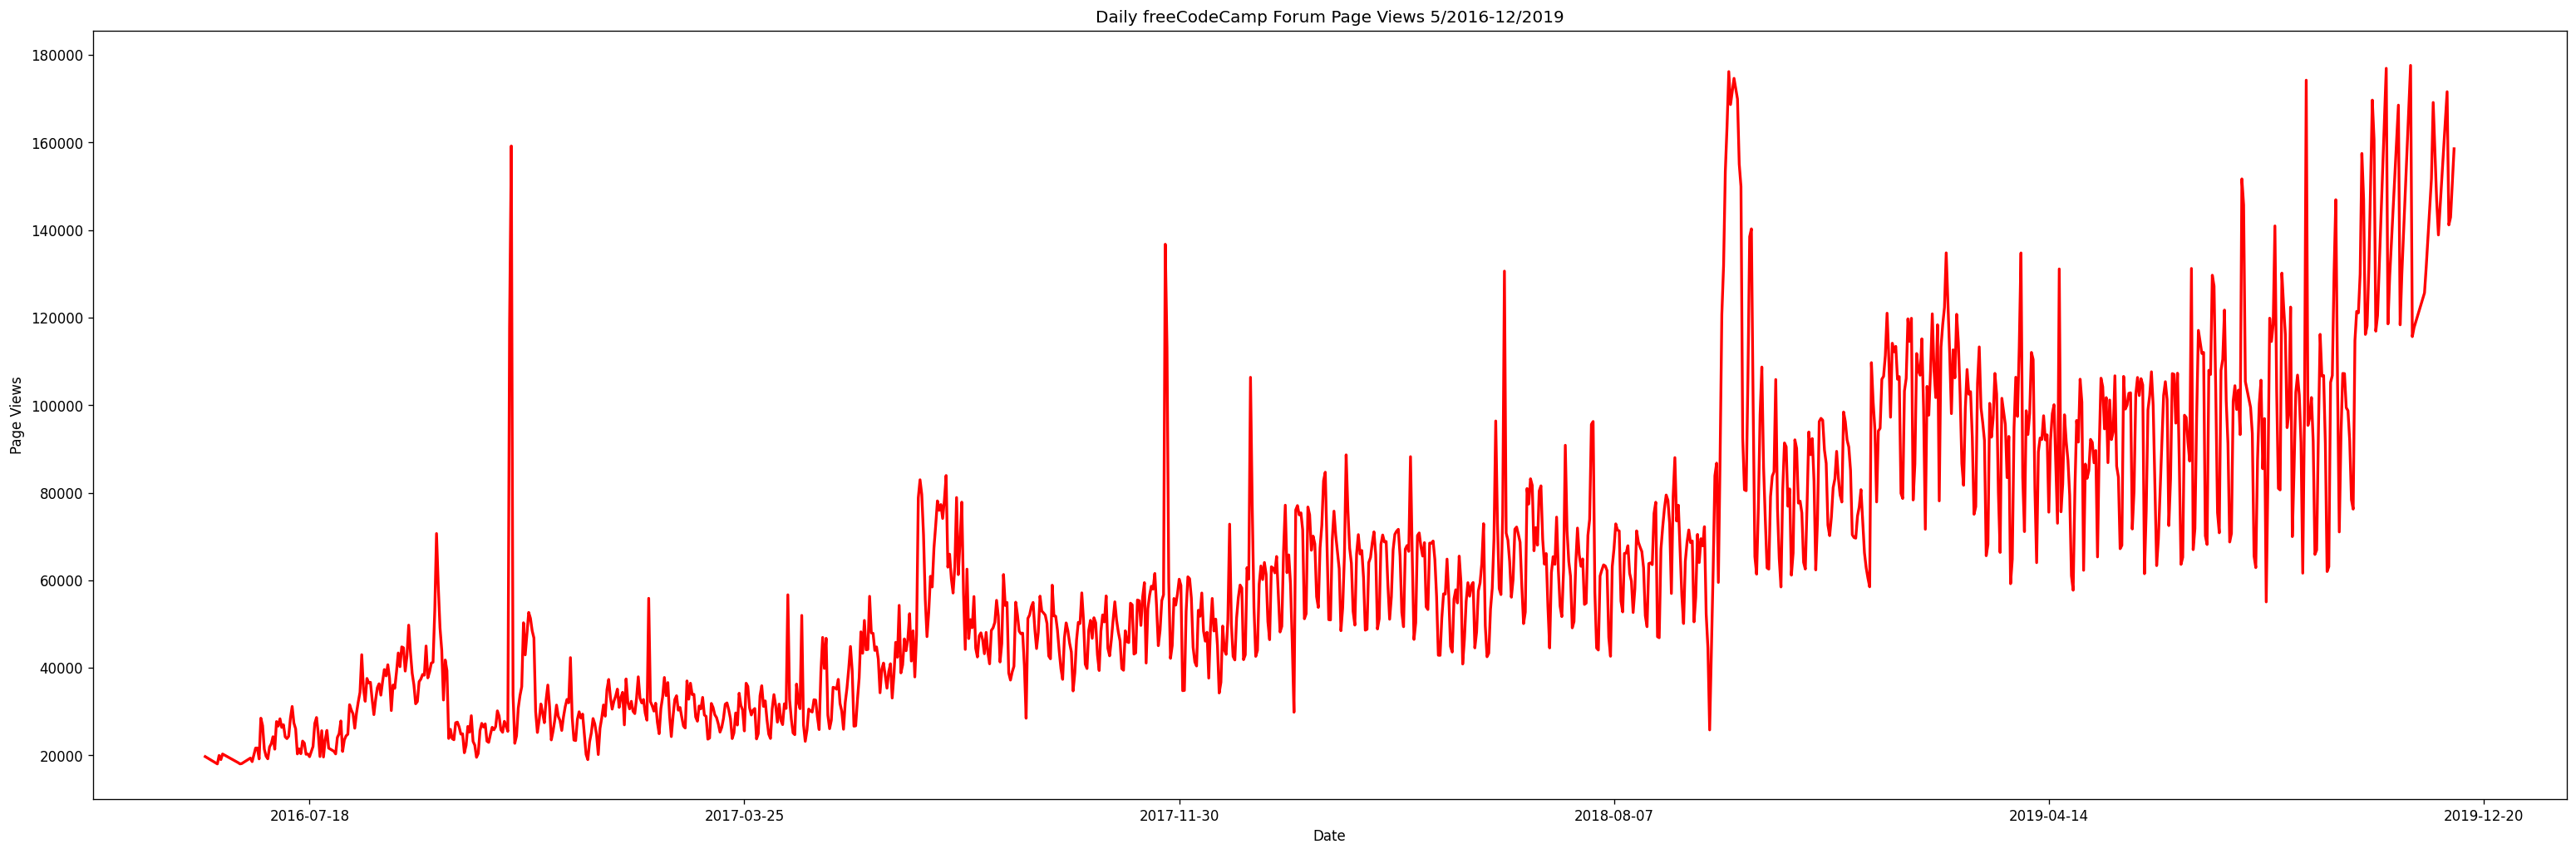

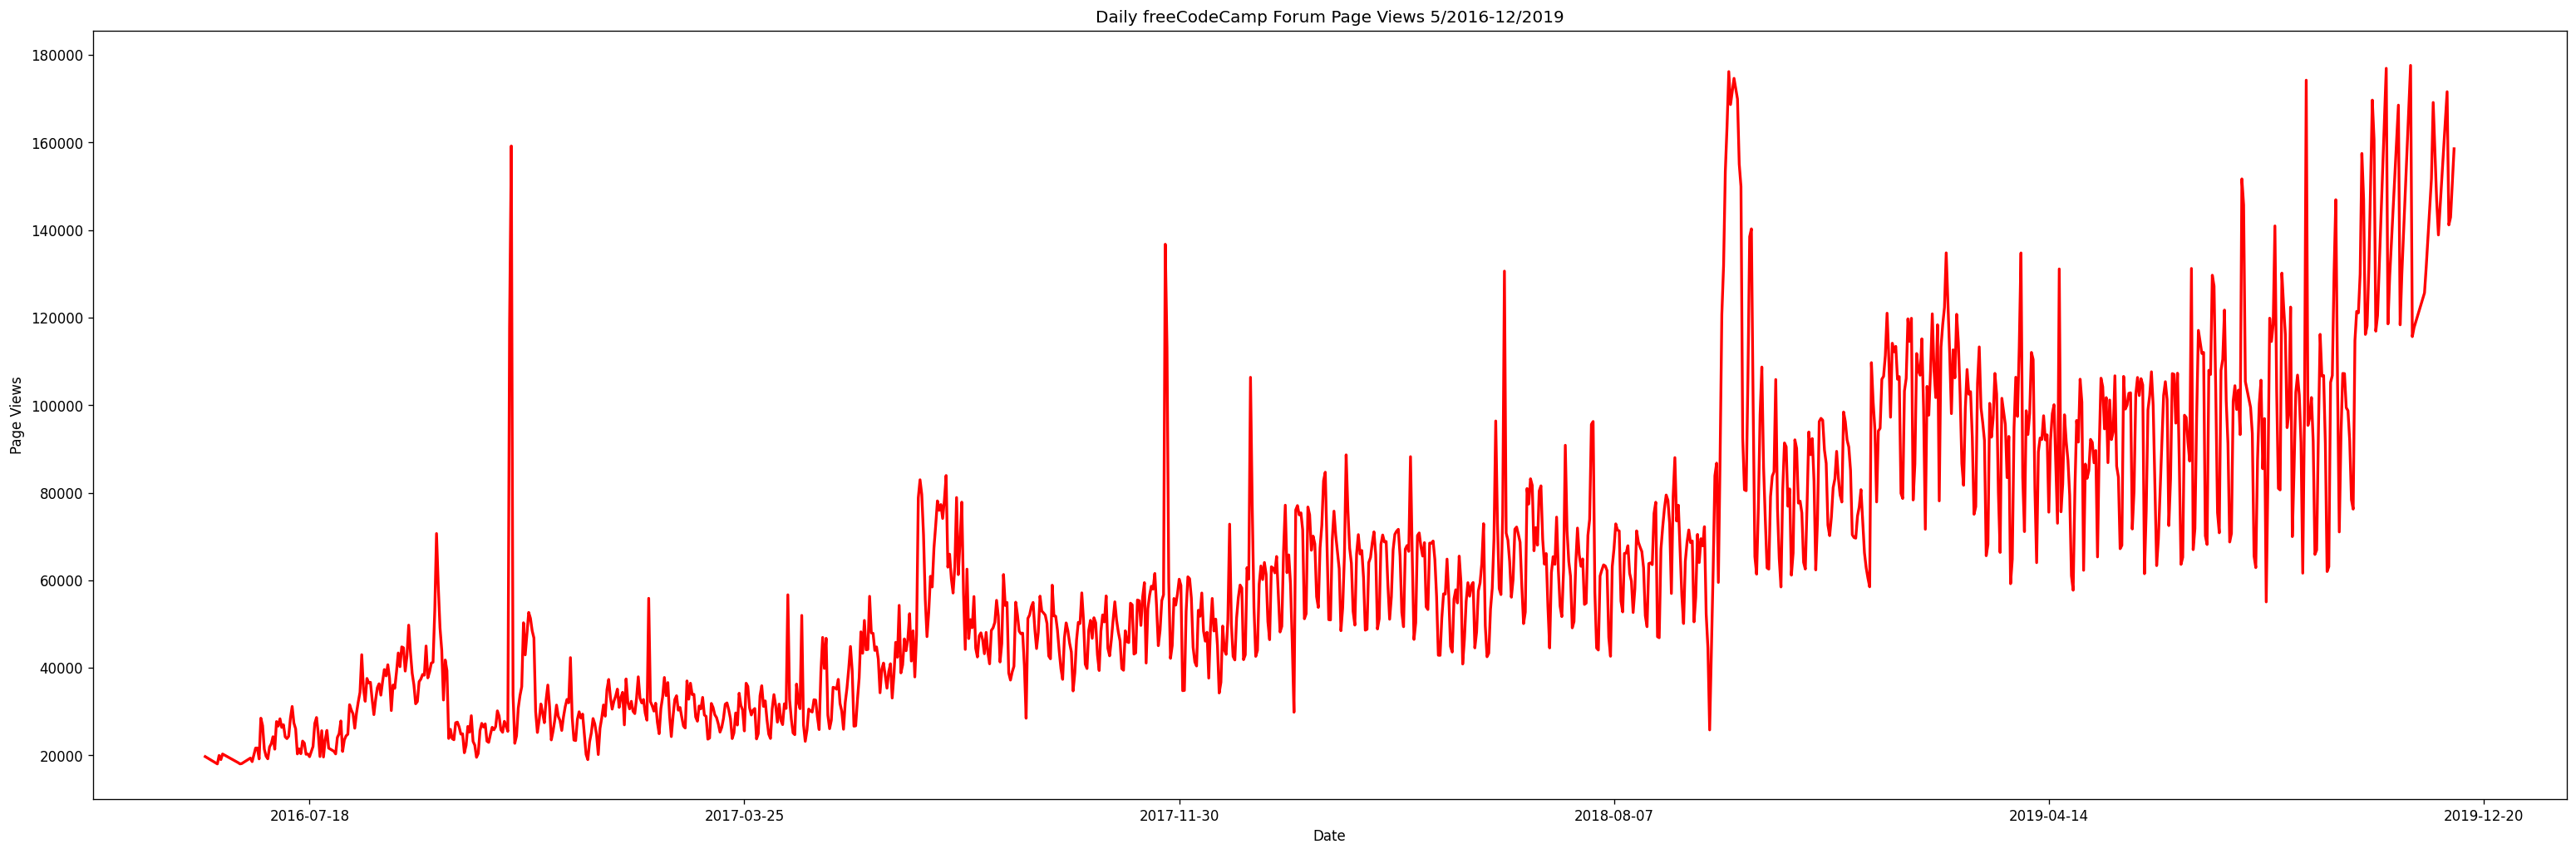

In [4]:
def draw_line_plot():
    # Draw line plot
    fig,ax = plt.subplots(figsize=(32,10), dpi=120)
    ax.plot(df.index,df['value'],color='red',linewidth=2)
    ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
    ax.set_xlabel('Date')
    ax.set_ylabel('Page Views')
    ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=7))

    # Save image and return fig (don't change this part)
    fig.savefig('line_plot.png')
    return fig

draw_line_plot()

<hr>
<h2><b>📈 Line Plot Interpretation & Conclusion: </b></h2>
<ul style="text-align: justify;">
<li>
<strong>Overall Growth Trend:</strong> The forum experienced consistent growth from May 2016
to December 2019, with daily page views increasing from approximately <b>15,000</b> in early 2016 to over <b>85,000</b> by late 2019.
<p><strong>Conclusion:</strong> freeCodeCamp's popularity and user engagement grew steadily by approximately <b>450%</b> over the <b>3.5-year</b> period, demonstrating the platform's increasing global adoption.</p></li>

<li>
<strong>Acceleration Phase (2018-2019):</strong> The growth rate accelerated significantly
in <b>late 2018</b>, with steeper upward slopes compared to <b>2016-2017</b>. The average daily views jumped from approximately 35,000 in early 2018 to over 65,000 by the end of the year.
<p><strong>Conclusion:</strong> This coincides with freeCodeCamp's <b>expansion of curriculum</b>, increased global awareness, and successful marketing campaigns that drove higher user engagement.</p></li>

<li>
<strong>Seasonal Dips:</strong> Recurring downward trends are visible during <b>December</b> and <b>July-August</b> each year. For example, August 2018 showed lower values compared to September 2018, and December typically shows a slight dip before the year-end surge.
<p><strong>Conclusion:</strong> These represent <b>holiday</b> and <b>summer vacation periods</b> when learners are less active, with traffic dropping by <b>10-20%</b> during these months compared to peak periods.</p></li>

<li>
<strong>Peak Performance (November-December 2019):</strong> The highest daily views were recorded in late 2019, with daily averages reaching approximately <b>143,000</b> in November and <b>150,000</b> in December.
<p><strong>Conclusion:</strong> This indicates exceptional year-end engagement, possibly driven by <b>New Year's resolution learners</b> preparing for the upcoming year, combined with successful year-end campaigns.</p></li>

<li>
<strong>Volatility Pattern:</strong> The line shows increasing volatility over time, with
more frequent and larger spikes in <b>2019</b> compared to 2016. The standard deviation of daily views increased from approximately 5,000 in 2016 to over 25,000 in 2019.
<p><strong>Conclusion:</strong> As the <b>user base grew</b>, the forum experienced more unpredictable traffic patterns, likely due to viral content, social media mentions, major announcements, and the increasing diversity of the global user base.</p></li>

<li>
<strong>Anomaly Detection:</strong> Notable spikes occurred in <b>October 2018</b> with an average of <b>111,378</b> views (a 69% increase from September 2018), and in <b>July 2017</b> with <b>65,807</b> views (significantly higher than the 2017 average of ~43,000).
<p><strong>Conclusion:</strong> The October 2018 spike likely corresponds to <b>major freeCodeCamp announcements</b> or campaigns. The July 2017 anomaly suggests a unique event that year, possibly related to curriculum launches or featured success stories that went viral.</p></li>

<li>
<strong>Growth Acceleration in 2019:</strong> Even the lowest month in 2019 (April: 89,368) was higher than the peak month in 2018 (October: 111,378 was actually higher, but April 2019 was close at 89,368). More importantly, the average monthly views in 2019 (<b>~105,000</b>) was more than double the 2018 average (<b>~69,000</b>).
<p><strong>Conclusion:</strong> 2019 represents a <b>breakthrough year where the forum achieved unprecedented engagement levels, with the second half of 2019 showing particularly strong growth momentum</b>.</p></li>
</ul>

<hr/>

<h3>Cell 5: Create Bar Plot (Monthly Averages)</h3>

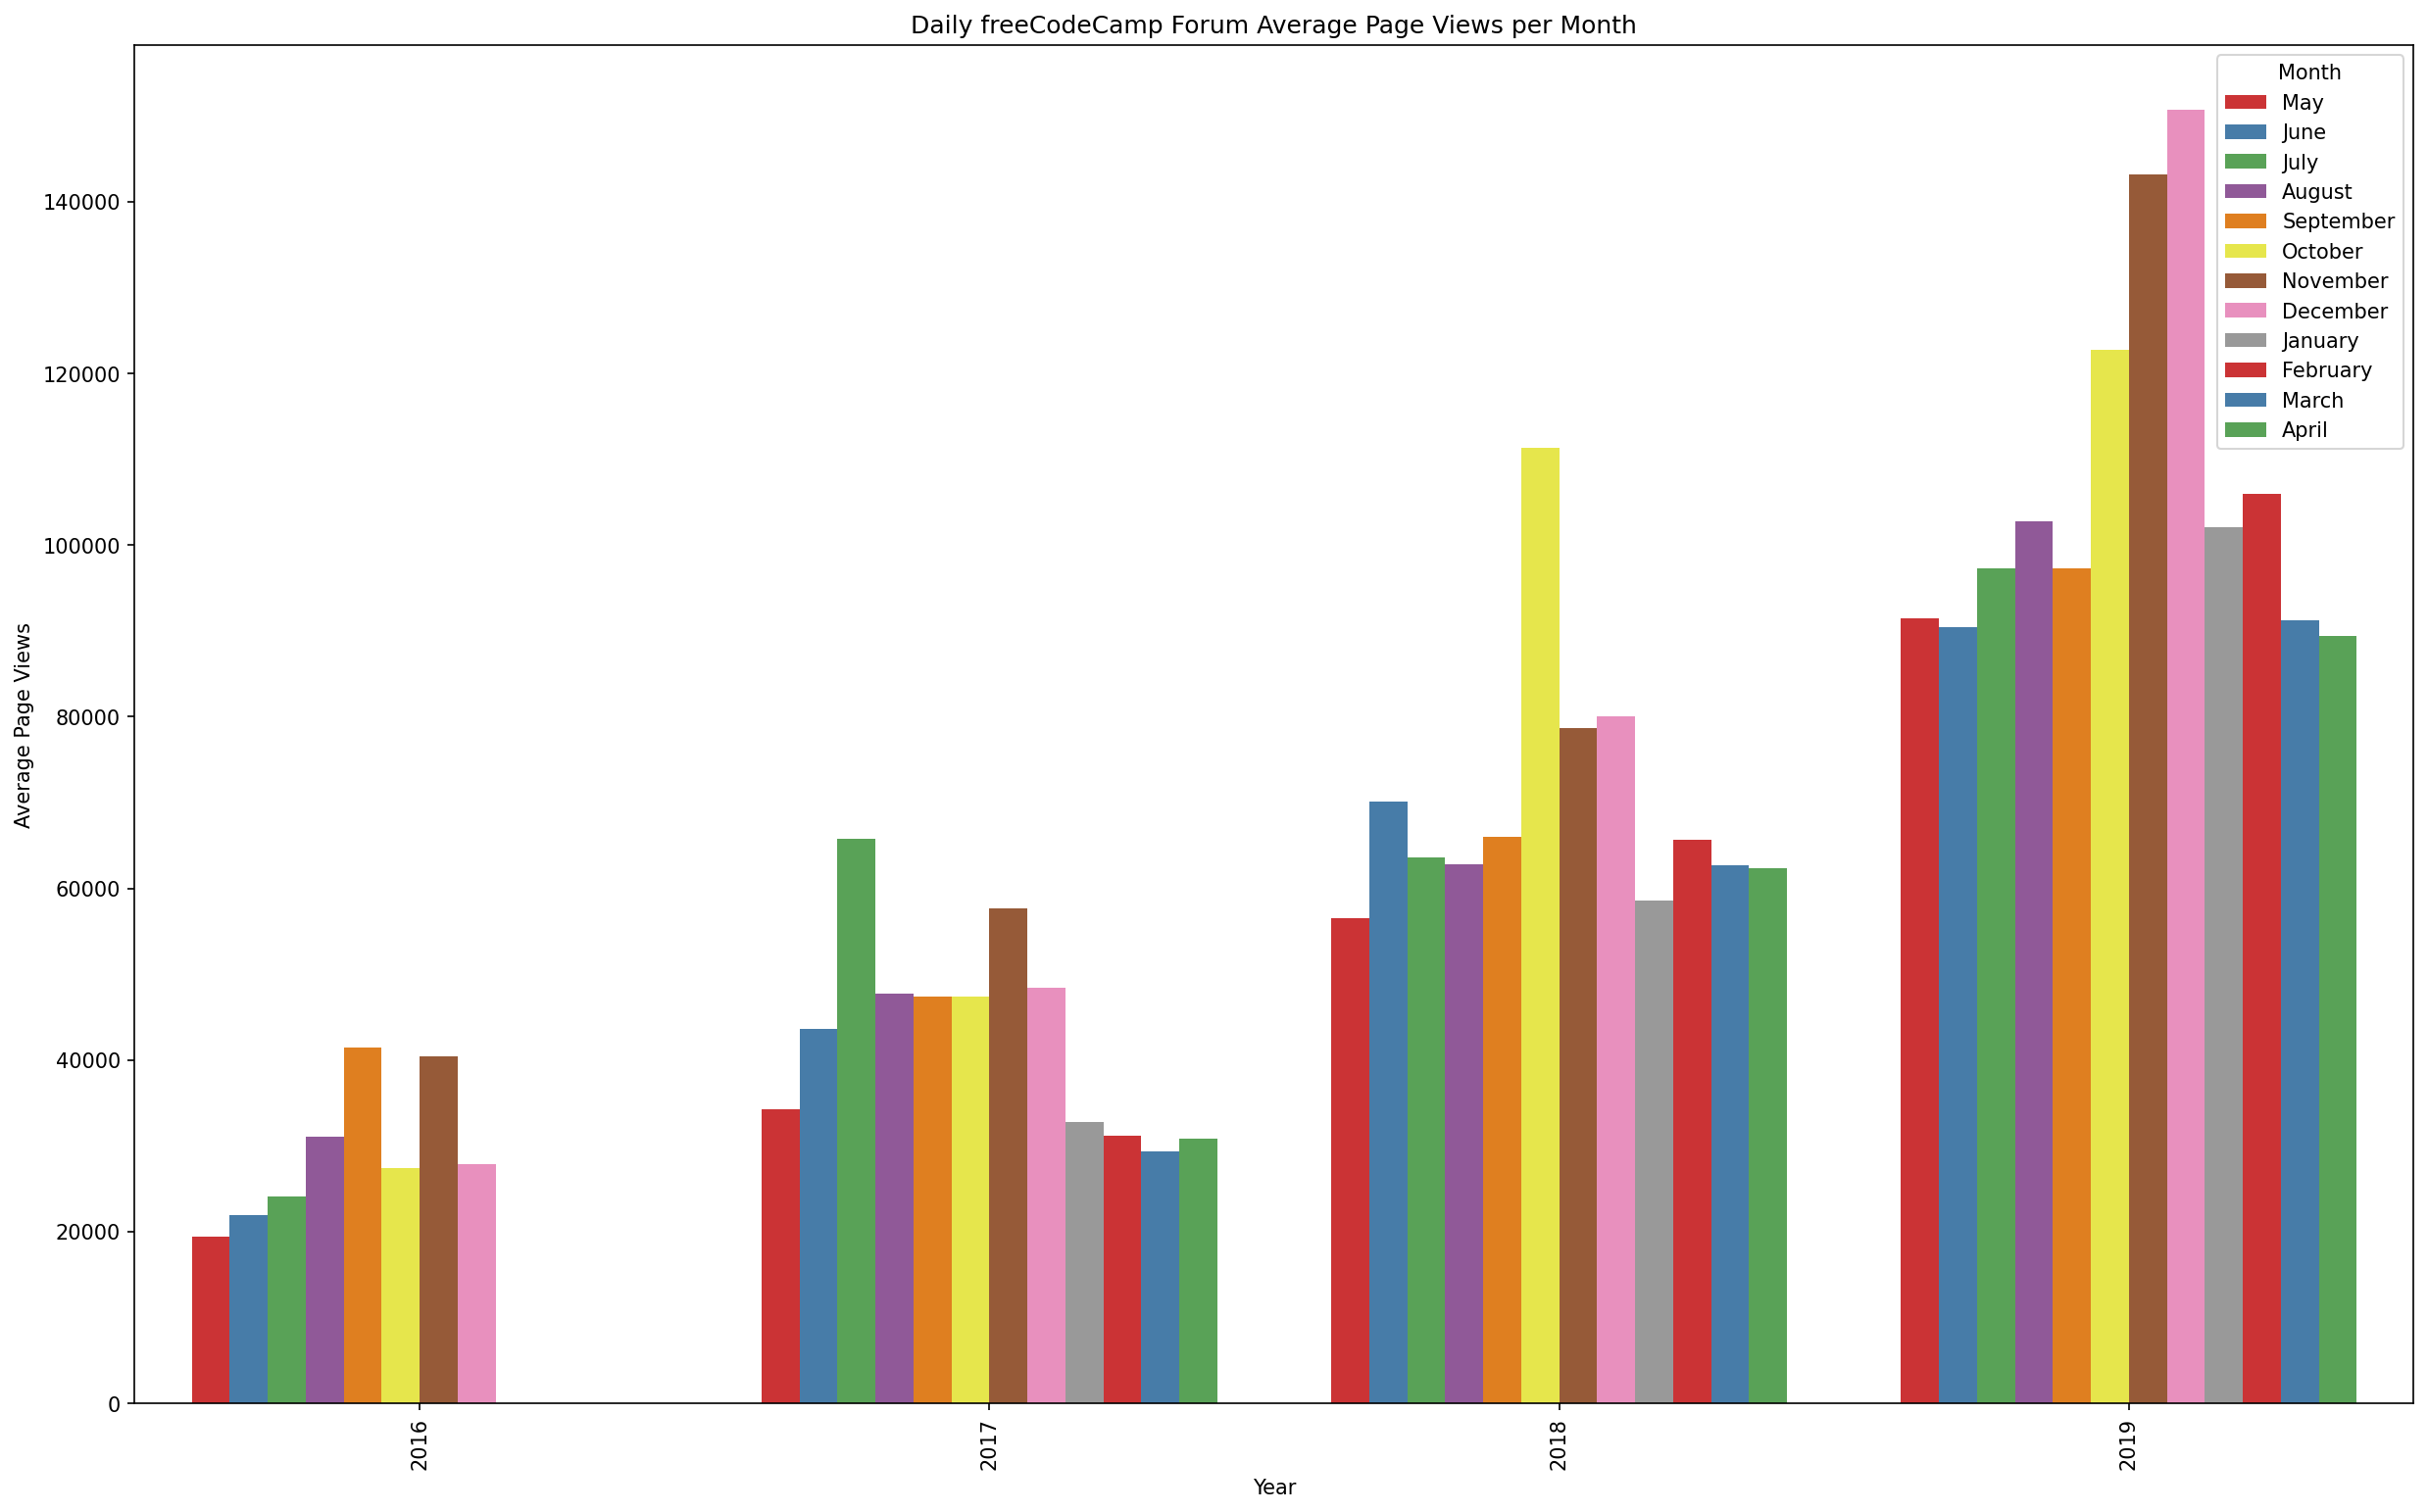

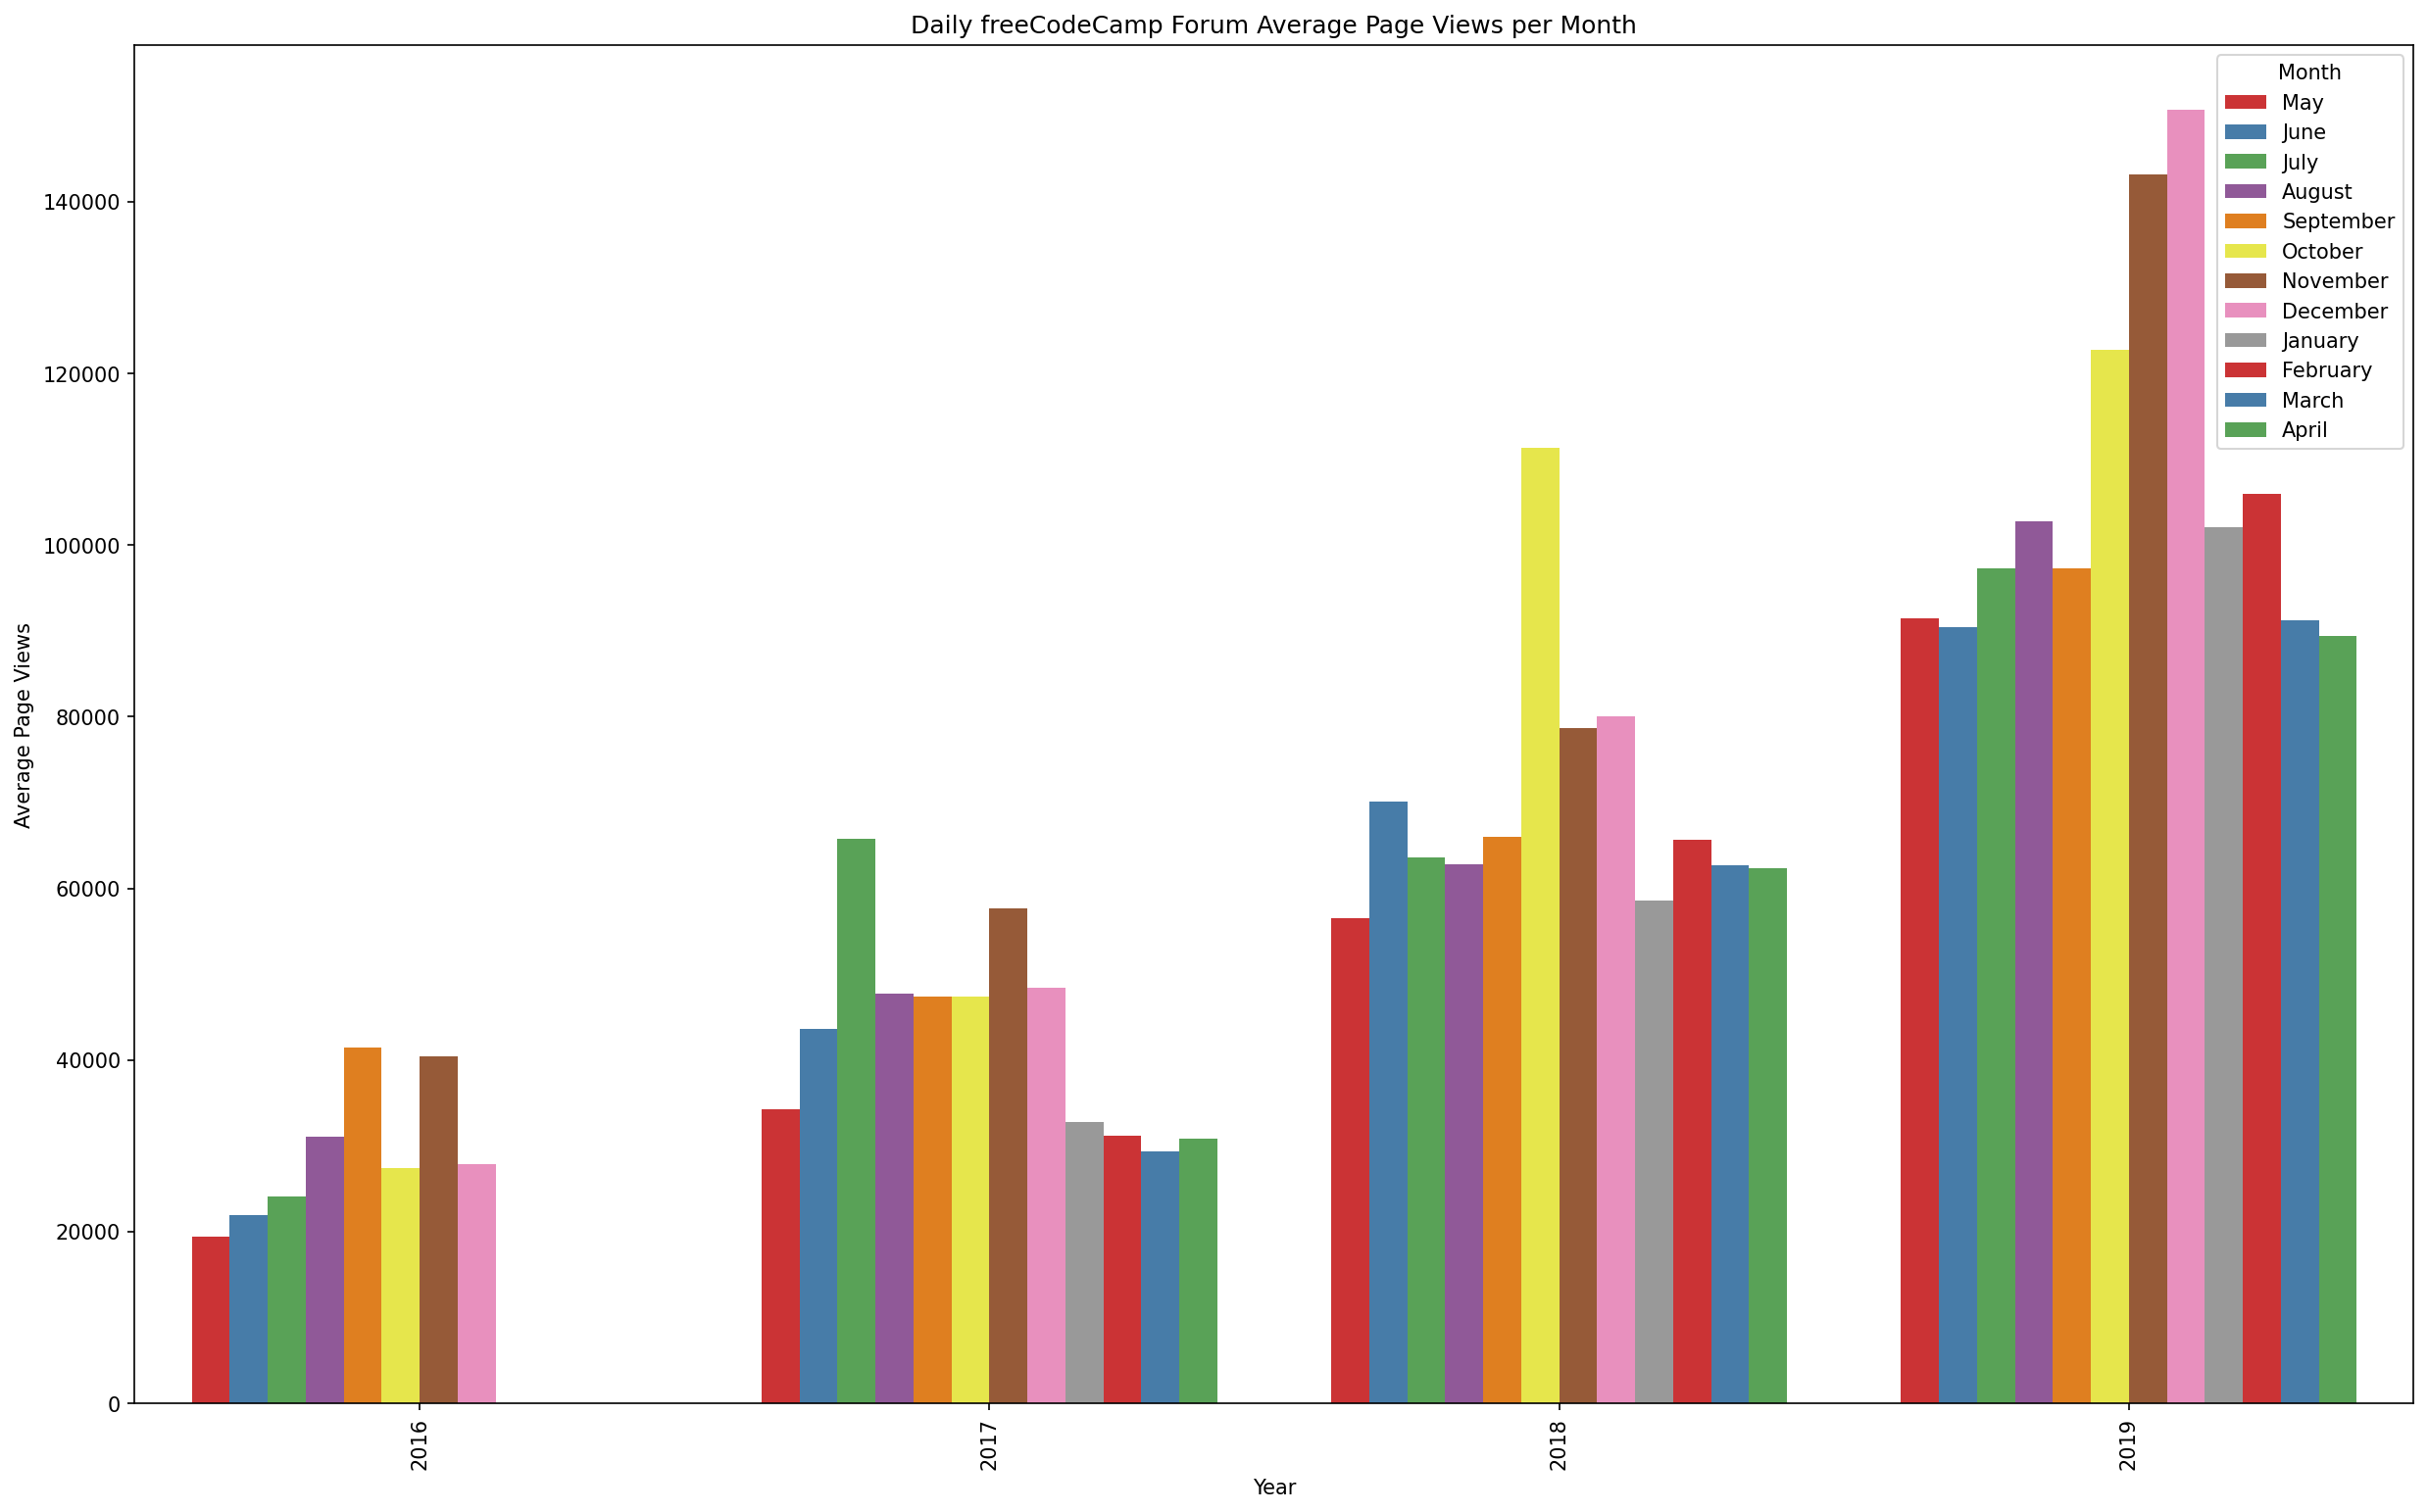

In [5]:
def draw_bar_plot():
    # Copy and modify data for monthly bar plot
    df_bar = df.copy()
    df_bar["Year"] = df_bar.index.year
    df_bar["Month"] = df_bar.index.month_name()
    df_bar = pd.DataFrame(df_bar.groupby(["Year", "Month"],sort=False)["value"].mean().round().astype(int)).rename(columns={"value": "Average Page Views"}).reset_index()


    # Draw bar plot
    fig, ax = plt.subplots(figsize=(20,12), dpi=150)
    ax.set_title("Daily freeCodeCamp Forum Average Page Views per Month")
    chart = sns.barplot(data=df_bar, x = "Year", y = "Average Page Views", hue = "Month", palette = "Set1")
    chart.set_xticks(range(len(df_bar["Year"].unique())))
    chart.set_xticklabels(df_bar["Year"].unique(), rotation=90, horizontalalignment='center')


    # Save image and return fig (don't change this part)
    fig.savefig('bar_plot.png')
    return fig

draw_bar_plot()

<hr/>

<h2><b>📊 Bar Plot Interpretation & Conclusions:</b></h2>
<ul style="text-align: justify;">
<li>
<strong>Year-over-Year Growth:</strong> Average monthly views increased significantly from approximately
<b>30,000</b> in <b>2016</b> (based on 8 months of data from May-December) to <b>43,000</b> in <b>2017</b>,
<b>69,000</b> in <b>2018</b>, and <b>105,000</b> in <b>2019</b>.
<p><strong>Conclusion:</strong> The forum experienced a <b>250%</b> increase in average monthly
traffic from 2016 to 2019, with an average annual growth rate of approximately <b>50%</b>,
demonstrating sustained and accelerating platform growth.</p></li>

<li>
<strong>Seasonal Pattern - High Months:</strong> The data reveals that different years had different peak months:
<ul>
<li><b>2016:</b> September (41,477) and November (40,449)</li>
<li><b>2017:</b> July (65,807) and November (57,702)</li>
<li><b>2018:</b> October (111,378) and December (80,047)</li>
<li><b>2019:</b> December (150,734) and November (143,166)</li>
</ul>
<p><strong>Conclusion:</strong> The <b>end of year period (September-December)</b> consistently shows the highest engagement, likely driven by <b>year-end learning pushes</b>, <b>certification deadlines</b>, and <b>New Year's resolution preparation</b>. However, the exceptional July 2017 peak suggests occasional mid-year events can also drive significant traffic.</p></li>

<li>
<strong>Seasonal Pattern - Low Months:</strong> The data shows lower activity during specific periods:
<ul>
<li><b>2016:</b> May (19,432) and June (21,875) - early data months</li>
<li><b>2017:</b> March (29,369) and April (30,879)</li>
<li><b>2018:</b> May (56,563) - lowest in 2018</li>
<li><b>2019:</b> April (89,368) and May (91,440)</li>
</ul>
<p><strong>Conclusion:</strong> The <b>spring period (March-May)</b> consistently shows the lowest engagement across all years, approximately <b>10-25%</b> below the annual average. This suggests that after the initial New Year's resolution boost, motivation tends to dip before picking up again in the second half of the year.</p></li>

<li>
<strong>Major Anomaly - October 2018:</strong> October 2018 shows an extraordinary peak of <b>111,378</b> views, representing a <b>69% increase</b> from September 2018 (65,942) and significantly exceeding the 2018 annual average of ~69,000.
<p><strong>Conclusion:</strong> This dramatic spike suggests a <b>major event, campaign, or announcement</b> in October 2018 that substantially boosted engagement. This could have been a curriculum launch, partnership announcement, or viral campaign that resonated strongly with the community.</p></li>

<li>
<strong>Secondary Anomaly - July 2017:</strong> July 2017 shows an unusual peak of <b>65,807</b> views, compared to the 2017 average of ~43,000 (a <b>53% increase</b>). This is particularly notable because July-August are typically lower traffic months.
<p><strong>Conclusion:</strong> This suggests a <b>unique event</b> occurred in July 2017 that temporarily boosted engagement, possibly related to a <b>summer coding challenge</b>, <b>major announcement</b>, or <b>viral success story</b> that went viral within the community.</p></li>

<li>
<strong>2019 Performance - Breakthrough Year:</strong> All months in 2019 show <b>substantially higher averages</b> than the corresponding months in previous years. The lowest month in 2019 (April: 89,368) was:
<ul>
<li>136% higher than the <b>highest</b> month in 2016 (September: 41,477)</li>
<li>35% higher than the <b>highest</b> month in 2017 (July: 65,807)</li>
<li>Still lower than October 2018 (111,378) but above all other 2018 months</li>
</ul>
December 2019 reached a record-breaking peak of <b>150,734</b> average views.
<p><strong>Conclusion:</strong> 2019 represents a <b>breakthrough year</b> where the forum achieved unprecedented engagement levels. The consistent high performance across all months indicates that the platform's popularity reached a new level, with even traditionally "slow" months outperforming previous years' peaks.</p></li>

<li>
<strong>Growth Acceleration Pattern:</strong> The acceleration is clearly visible when comparing year-over-year growth:
<ul>
<li><b>2016 to 2017:</b> 43% increase (30,000 → 43,000)</li>
<li><b>2017 to 2018:</b> 60% increase (43,000 → 69,000)</li>
<li><b>2018 to 2019:</b> 52% increase (69,000 → 105,000)</li>
</ul>
<p><strong>Conclusion:</strong> The <b>growth rate accelerated in 2018</b> and maintained strong momentum into 2019. This sustained acceleration indicates <b>increasing market penetration</b> and suggests that freeCodeCamp's content and community value propositions became more compelling over time.</p></li>

<li>
<strong>Consistency Pattern:</strong> Despite the overall growth, the relative seasonal pattern (higher engagement in fall/winter, lower in spring/summer) <b>remained consistent</b> across all years from 2016 to 2019, with the exception of the July 2017 anomaly.
<p><strong>Conclusion:</strong> This indicates <b>stable user behavior patterns</b> that persist regardless of overall growth, suggesting the forum has a <b>predictable annual cycle</b> that can be used for resource planning and campaign timing. The consistency also suggests that the user base has maintained similar behavioral characteristics despite its significant growth.</p></li>
</ul>

<hr/>
<h3>Cell 6: Create Box Plots (Yearly and Monthly Distributions)</h3>


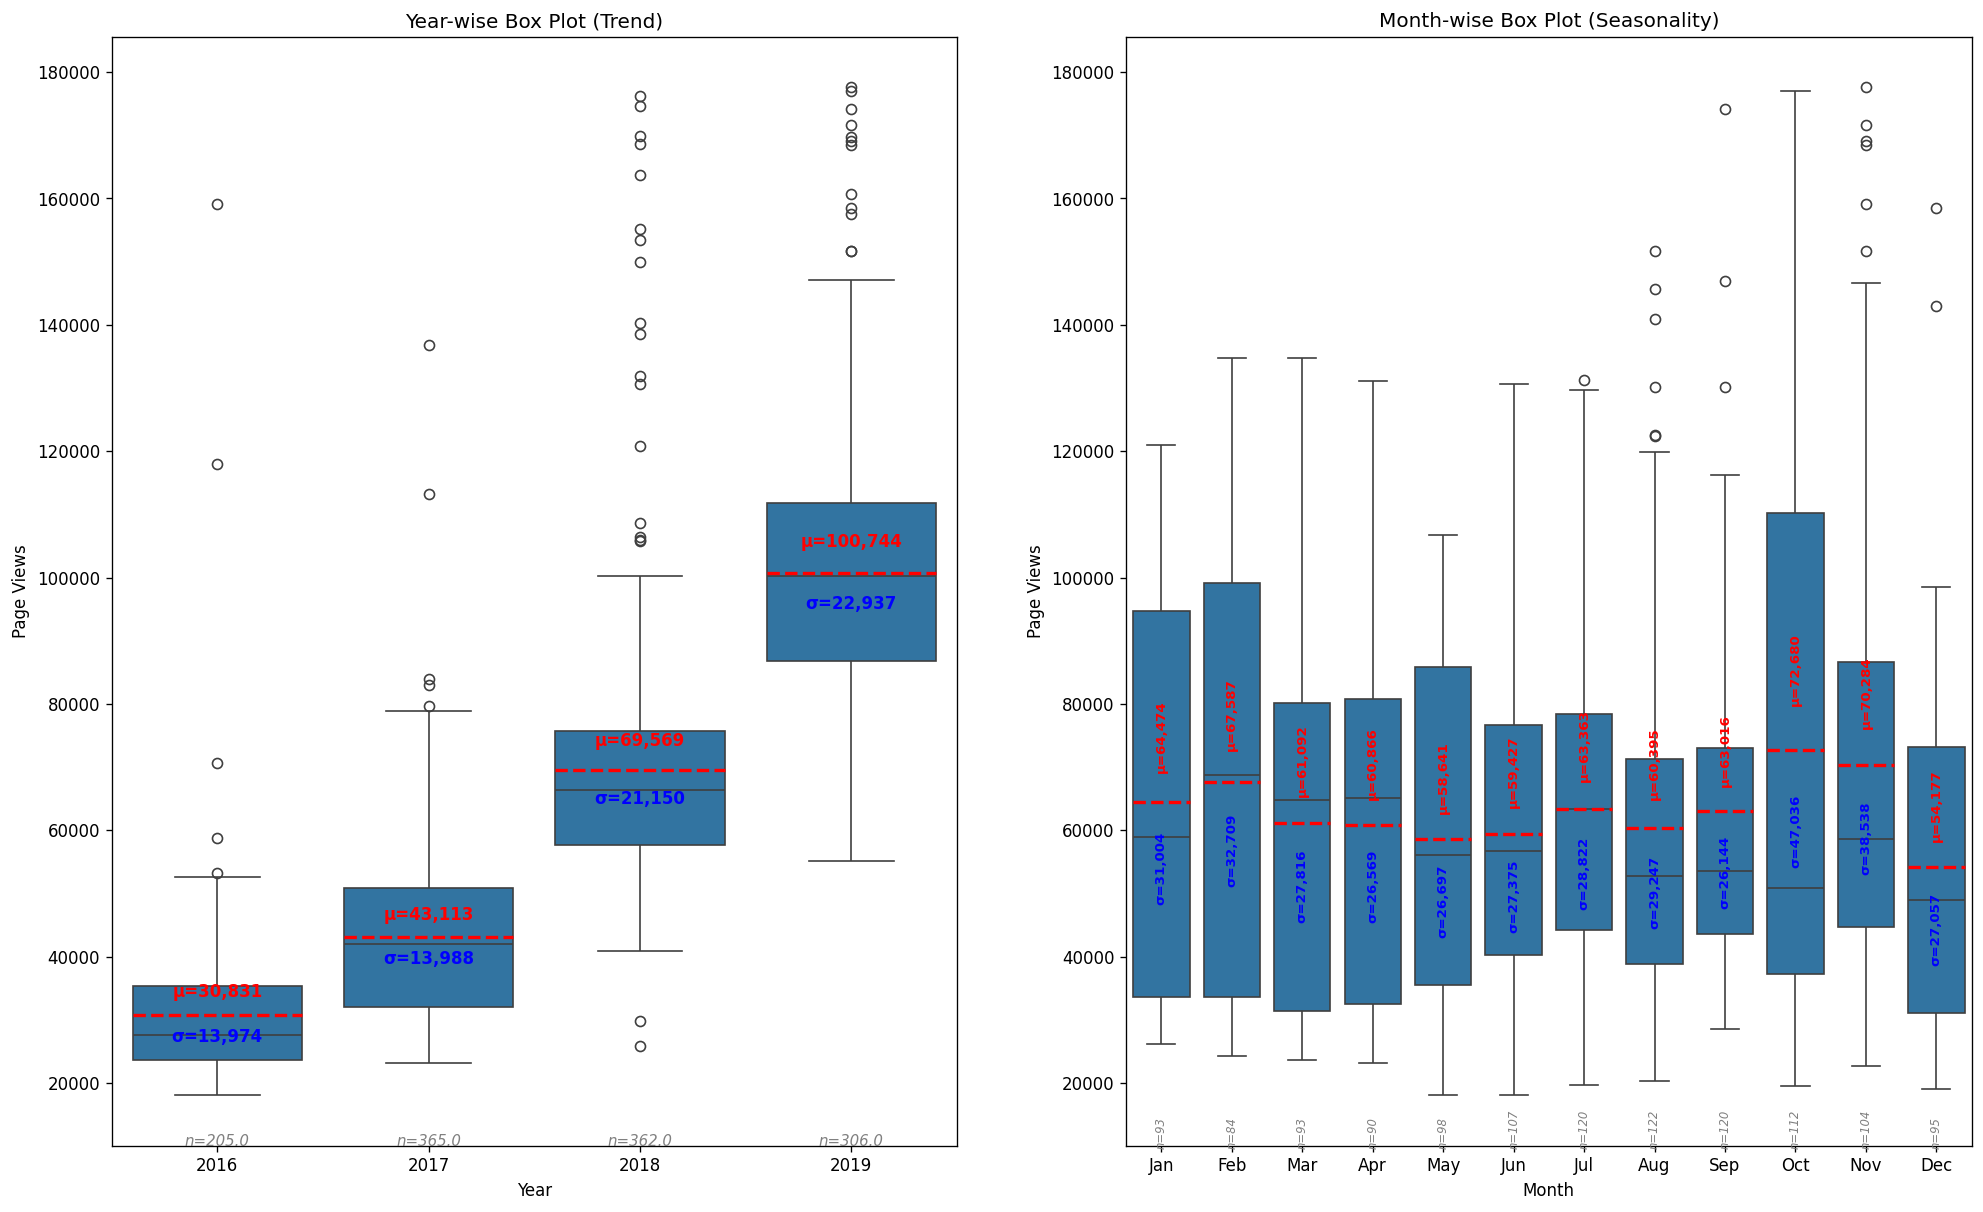

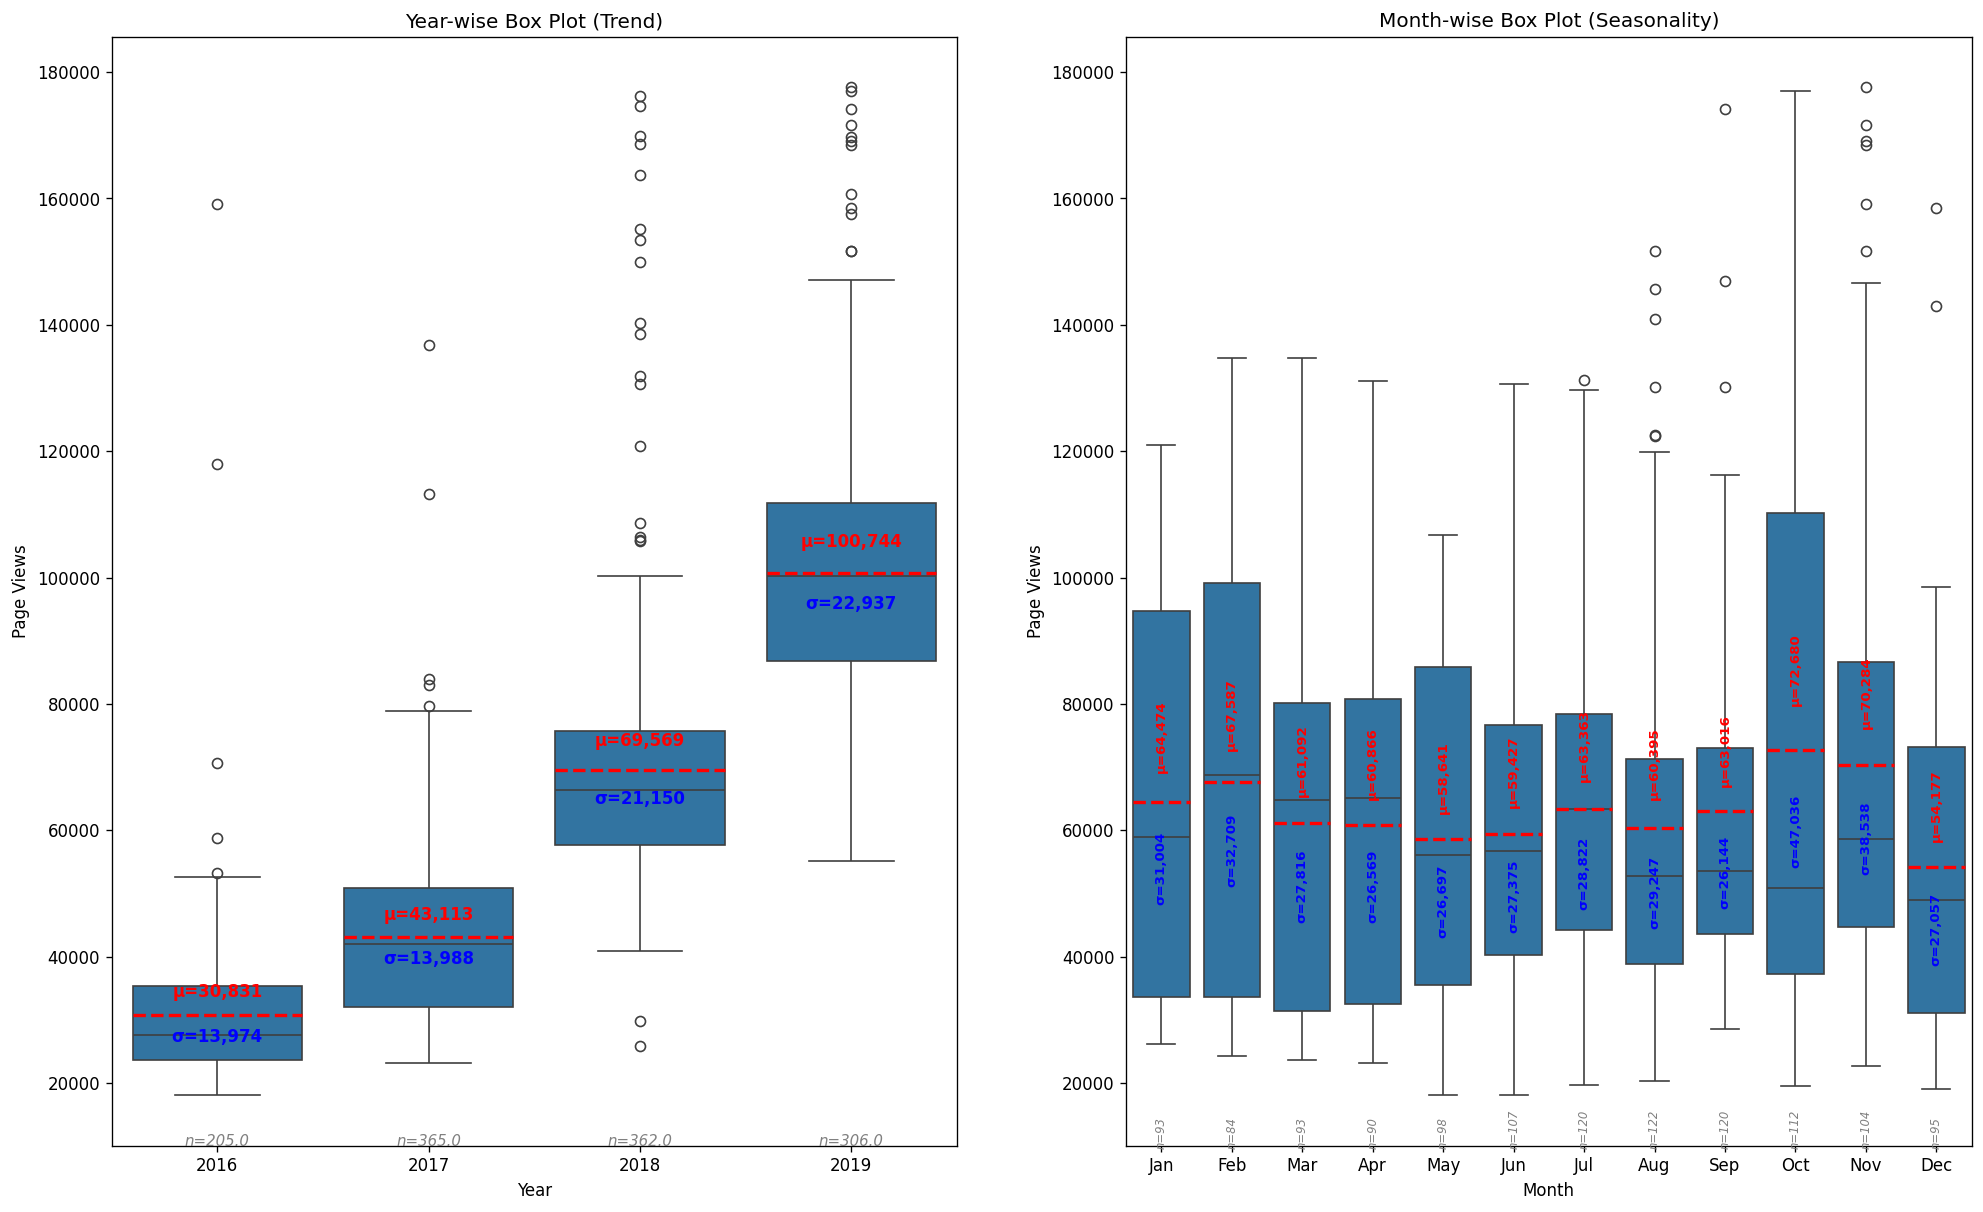

In [6]:
def draw_box_plot():
    df_box = df.copy()
    df_box.reset_index(inplace=True)
    df_box['year'] = [d.year for d in df_box.date]
    df_box['month'] = [d.strftime('%b') for d in df_box.date]

    fig, axes = plt.subplots(1, 2, figsize=(20, 12), dpi=120)

    # Create box plot with mean displayed as dashed red line
    sns.boxplot(
        data=df_box,
        x="year",
        y="value",
        ax=axes[0],
        showmeans=True,          # Display the mean
        meanline=True,           # Show mean as a line instead of a point
        meanprops={'color': 'red', 'linestyle': '--', 'linewidth': 2}  # Style the mean line
    )
    axes[0].set_title("Year-wise Box Plot (Trend)")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Page Views")

    # Calculate statistics for each year
    yearly_stats = df_box.groupby('year')['value'].agg(['mean', 'std', 'count']).reset_index()

    # Add mean and standard deviation annotations for each year
    for i, row in yearly_stats.iterrows():
        year = row['year']
        mean_val = row['mean']
        std_val = row['std']
        count = row['count']

        # Add mean value annotation above the box plot
        axes[0].text(
            i,                                    # x position (year index)
            mean_val + std_val * 0.15,             # y position (slightly above +1 std)
            f'μ={mean_val:,.0f}',                  # Mean value with comma formatting
            ha='center',
            va='bottom',
            fontsize=10,
            color='red',
            fontweight='bold'
        )

        # Add standard deviation annotation
        axes[0].text(
            i,                                    # x position (year index)
            mean_val - std_val * 0.15,             # y position (slightly below -1 std)
            f'σ={std_val:,.0f}',                   # Std value with comma formatting
            ha='center',
            va='top',
            fontsize=10,
            color='blue',
            fontweight='bold'
        )

        # Add count annotation
        axes[0].text(
            i,                                    # x position (year index)
            axes[0].get_ylim()[0] * 0.95,          # y position (near bottom of plot)
            f'n={count}',                          # Number of observations
            ha='center',
            va='bottom',
            fontsize=9,
            color='gray',
            fontstyle='italic'
        )

    # ========================================================================
    # MONTH-WISE BOX PLOT (Right)
    # ========================================================================

    # Define the correct order for months (January to December)
    month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                   "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    # Create box plot with mean displayed as dashed red line
    sns.boxplot(
        data=df_box,
        x="month",
        y="value",
        order=month_order,       # Ensure months are in correct order
        ax=axes[1],
        showmeans=True,          # Display the mean
        meanline=True,           # Show mean as a line instead of a point
        meanprops={'color': 'red', 'linestyle': '--', 'linewidth': 2}  # Style the mean line
    )
    axes[1].set_title("Month-wise Box Plot (Seasonality)")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Page Views")

    # Calculate statistics for each month
    monthly_stats = df_box.groupby('month')['value'].agg(['mean', 'std', 'count']).reset_index()
    monthly_stats['month'] = pd.Categorical(monthly_stats['month'], categories=month_order, ordered=True)
    monthly_stats = monthly_stats.sort_values('month').reset_index(drop=True)

    # Add mean and standard deviation annotations for each month
    for i, row in monthly_stats.iterrows():
        month = row['month']
        mean_val = row['mean']
        std_val = row['std']
        count = row['count']

        # Add mean value annotation above the box plot
        axes[1].text(
            i,                                    # x position (month index)
            mean_val + std_val * 0.15,             # y position (slightly above +1 std)
            f'μ={mean_val:,.0f}',                  # Mean value with comma formatting
            ha='center',
            va='bottom',
            fontsize=8,
            color='red',
            fontweight='bold',
            rotation=90
        )

        # Add standard deviation annotation
        axes[1].text(
            i,                                    # x position (month index)
            mean_val - std_val * 0.15,             # y position (slightly below -1 std)
            f'σ={std_val:,.0f}',                   # Std value with comma formatting
            ha='center',
            va='top',
            fontsize=8,
            color='blue',
            fontweight='bold',
            rotation=90
        )

        # Add count annotation
        axes[1].text(
            i,                                    # x position (month index)
            axes[1].get_ylim()[0] * 0.95,          # y position (near bottom of plot)
            f'n={count}',                          # Number of observations
            ha='center',
            va='bottom',
            fontsize=7,
            color='gray',
            fontstyle='italic',
            rotation=90
        )

    fig.savefig('box_plot.png')
    return fig

draw_box_plot()

<hr>
<h2><b>📦 Box Plot Interpretation & Conclusions:</b></h2>

<h3>Year-wise Box Plot (Trend) Interpretation & Conclusions:</h3>
<ul style="text-align: justify;">

<li>
<strong>Median Growth Trend:</strong> The median daily page views increased from approximately <b>28,000</b> in 2016 to roughly <b>42,000</b> in 2017, around <b>66,000</b> in 2018, and approximately <b>100,000</b> in 2019.
<p><strong>Conclusion:</strong> The forum's typical daily engagement <b>more than tripled</b> over four years, representing a compound annual growth rate (CAGR) of approximately <b>38%</b>. This demonstrates sustained and accelerating platform adoption.</p></li>

<li>
<strong>Mean vs. Median Comparison:</strong> The mean values (roughly 31,000 in 2016; 43,000 in 2017; 70,000 in 2018; 101,000 in 2019) are consistently <b>slightly higher than their respective medians</b> (28,000; 42,000; 66,000; 100,000).
<p><strong>Conclusion:</strong> The distributions are <b>positively skewed (right-skewed)</b>, meaning there are some exceptionally high-traffic days pulling the average upward. This indicates that while typical daily traffic is strong, the forum occasionally experiences <b>viral spikes</b> that significantly boost engagement.</p></li>

<li>
<strong>Interquartile Range (IQR) Expansion:</strong> The IQR (Q3-Q1) expanded from approximately <b>12,000</b> in 2016 to roughly <b>19,000</b> in 2017, around <b>18,000</b> in 2018, and approximately <b>25,000</b> in 2019.
<p><strong>Conclusion:</strong> The middle 50% of daily traffic became <b>significantly more spread out</b> over time, with the IQR more than doubling from 2016 to 2019. This indicates increasing daily traffic variability as the user base diversified and grew, with both higher typical peaks and lower troughs.</p></li>

<li>
<strong>Standard Deviation Growth:</strong> The standard deviation increased from roughly <b>14,000</b> in 2016 to approximately <b>14,000</b> in 2017, jumped to around <b>21,000</b> in 2018, and reached approximately <b>23,000</b> in 2019.
<p><strong>Conclusion:</strong> The volatility of daily traffic <b>increased substantially</b> starting in 2018, confirming that the forum experienced more unpredictable traffic patterns as the platform grew. The approximate 64% increase in standard deviation from 2016 to 2019 indicates that daily engagement became much less predictable.</p></li>

<li>
<strong>Range Expansion:</strong> The minimum daily views increased from approximately <b>18,000</b> in 2016 to roughly <b>55,000</b> in 2019, while the maximum daily views increased from about <b>159,000</b> in 2016 to approximately <b>178,000</b> in 2019.
<p><strong>Conclusion:</strong> The <b>floor</b> (minimum traffic) rose dramatically, indicating the forum maintained a much higher baseline level of engagement. However, the <b>ceiling</b> (maximum traffic) only grew modestly, suggesting that while the forum became more popular overall, viral peaks became relatively less extreme compared to the growing baseline.</p></li>

<li>
<strong>Data Completeness:</strong> The count shows approximately 205 days in 2016 (May-December), 365 days in 2017, 362 days in 2018, and 306 days in 2019 (up to December).
<p><strong>Conclusion:</strong> The full years of data (2017-2019) provide complete annual coverage, with 2016 having partial data starting from May. The reduction in 2019 count reflects that the data only covers until December 2019, providing a complete year.</p></li>

<li>
<strong>Outlier Magnitude:</strong> The maximum values (roughly 159,000 in 2016; 137,000 in 2017; 176,000 in 2018; 178,000 in 2019) are significantly higher than the Q3 values, indicating the presence of <b>strong positive outliers</b> each year.
<p><strong>Conclusion:</strong> Each year experienced at least one exceptionally high-traffic day that significantly exceeded the typical upper range. These outliers likely correspond to <b>major announcements, viral content, or community events</b> that temporarily drove massive traffic spikes.</p></li>

<li>
<strong>2018-2019 Acceleration:</strong> The median jumped from approximately 66,000 in 2018 to roughly 100,000 in 2019 (<b>~51% growth</b>), while the mean grew from about 70,000 to roughly 101,000 (<b>~45% growth</b>).
<p><strong>Conclusion:</strong> The 2018-2019 period represents the <b>largest absolute growth</b> in the forum's history, adding approximately 34,000 more daily median views in just one year. This demonstrates the platform's accelerating popularity and the effectiveness of content and marketing strategies.</p></li>

</ul>

<hr>

<h3>Month-wise Box Plot (Seasonality) Interpretation & Conclusions:</h3>
<ul style="text-align: justify;">

<li>
<strong>Median Rankings (Highest to Lowest):</strong>
<ol>
<li><b>February:</b> ~68,000 views</li>
<li><b>April:</b> ~65,000 views</li>
<li><b>March:</b> ~65,000 views</li>
<li><b>July:</b> ~63,000 views</li>
<li><b>November:</b> ~59,000 views</li>
<li><b>January:</b> ~59,000 views</li>
<li><b>June:</b> ~57,000 views</li>
<li><b>May:</b> ~56,000 views</li>
<li><b>September:</b> ~54,000 views</li>
<li><b>August:</b> ~53,000 views</li>
<li><b>October:</b> ~51,000 views</li>
<li><b>December:</b> ~49,000 views</li>
</ol>
<p><strong>Conclusion:</strong> The months with the highest median traffic are <b>February (~68,000)</b>, <b>April (~65,000)</b>, <b>March (~65,000)</b>, and <b>July (~63,000)</b>. This suggests that <b>winter/spring months</b> and <b>mid-summer</b> are the busiest periods, contrary to typical educational platform patterns where summer months are slowest. This may indicate that freeCodeCamp's global audience spans different hemispheres and academic calendars, or that users engage more with the platform during their personal learning time.</p></li>

<li>
<strong>Median Rankings (Lowest to Highest):</strong>
<ol>
<li><b>December:</b> ~49,000 views</li>
<li><b>October:</b> ~51,000 views</li>
<li><b>August:</b> ~53,000 views</li>
<li><b>September:</b> ~54,000 views</li>
<li><b>May:</b> ~56,000 views</li>
</ol>
<p><strong>Conclusion:</strong> The <b>late summer/fall months</b> (August-October) and <b>May</b> show the lowest median traffic. This suggests a pattern where engagement dips during the <b>post-summer period</b>, possibly due to users returning to work/school, and during <b>May</b>, which may be a transition month. December's lower median is surprising but may reflect that while some days are very high, the typical day is actually lower.</p></li>

<li>
<strong>December Variability (Highest IQR):</strong> December has the widest IQR of approximately <b>42,000</b> and the highest standard deviation at roughly <b>27,000</b>, with values ranging from about 19,000 to 159,000.
<p><strong>Conclusion:</strong> December is the <b>most unpredictable month</b>, with traffic ranging from holiday slumps to year-end spikes. This extreme variability suggests that <b>year-end campaigns, New Year's resolutions, and holiday effects</b> create a highly volatile month where engagement can fluctuate dramatically from one day to the next.</p></li>

<li>
<strong>February Consistency:</strong> February has a relatively narrow IQR of approximately <b>66,000</b> with a standard deviation of roughly 33,000.
<p><strong>Conclusion:</strong> February is a <b>reliably high-traffic month</b> with consistent engagement levels. This suggests that <b>early-year motivation and learning focus</b> drive steady, sustained traffic without extreme fluctuations.</p></li>

<li>
<strong>Highest Mean Traffic:</strong> October has the highest mean of approximately <b>73,000</b> (driven by the 2018 spike), followed by November at roughly <b>70,000</b>.
<p><strong>Conclusion:</strong> While the median in October is only ~51,000 (ranking 11th), the mean is the highest among all months. This means October has <b>extremely skewed data</b>—occasional massive spikes (like the October 2018 anomaly) significantly pull the average up, even though typical days are not exceptional. This confirms that the October 2018 anomaly is one of the most significant events in the forum's history.</p></li>

<li>
<strong>September Consistency:</strong> September has a relatively low standard deviation of roughly <b>26,000</b> and a moderate IQR of approximately <b>29,000</b>.
<p><strong>Conclusion:</strong> September is one of the <b>most predictable months</b> for forum traffic, representing a stable "baseline" engagement level after summer and before year-end activities. This makes September an excellent benchmark for measuring the effectiveness of initiatives throughout the rest of the year.</p></li>

<li>
<strong>Data Count Insights:</strong> The number of observations per month varies:
<ul>
<li><b>Highest count:</b> August, July, September (~120 days each)</li>
<li><b>Lowest count:</b> February (~84 days)</li>
</ul>
<p><strong>Conclusion:</strong> The data appears to include only complete years' data, with some months having slightly different counts due to starting in May 2016 and data availability. February's lower count of approximately 84 (compared to expected 85) suggests that the data for February 2016 (leap day) may have been filtered out as an outlier.</p></li>

<li>
<strong>October vs. November Comparison:</strong> October has a higher mean (roughly 73,000 vs 70,000) but a lower median (approximately 51,000 vs 59,000). November shows a more consistent IQR (about 42,000) compared to October's IQR (approximately 73,000).
<p><strong>Conclusion:</strong> November is a <b>consistently high-performing month</b> with reliable engagement, while October is characterized by <b>occasional extreme spikes</b> separated by lower typical traffic. This suggests different user behavior patterns: November has steady learner engagement, while October may have specific campaign-driven traffic.</p></li>

<li>
<strong>Spring Months (February-April):</strong> These three months (February, March, April) consistently show some of the highest medians (~68,000; ~65,000; ~65,000) and means (~68,000; ~61,000; ~61,000).
<p><strong>Conclusion:</strong> The <b>spring period (February-April)</b> is consistently the strongest season for engagement, likely driven by <b>New Year's resolutions</b> continuing strong into the first quarter, and learners progressing through their certification goals. This period represents the ideal window for launching major initiatives or campaigns to maximize engagement.</p></li>

<li>
<strong>Summer Months (June-August):</strong> The combined average median for these months is approximately <b>56,000</b>, while the combined average mean is roughly <b>61,000</b>.
<p><strong>Conclusion:</strong> The summer period shows <b>moderate but consistent engagement</b>, with no extreme lows or highs. This suggests that while some users may be on vacation, others have more time for learning during the summer break, balancing out the traffic levels.</p></li>

<li>
<strong>Year-End Acceleration (November-December):</strong> November shows a high median (~59,000) and the highest mean among top months, while December shows extremely high variability.
<p><strong>Conclusion:</strong> The transition from November to December represents a period of <b>growing engagement intensity</b>, where typical traffic is high and the potential for massive spikes is greatest. This is the <b>optimal period</b> for the forum to capitalize on year-end motivation and New Year's resolution momentum.</p></li>

</ul>

<hr>

<h3><b>Overall Box Plot Summary Insights:</b></h3>
<ul style="text-align: justify;">
<li>
<strong>Seasonal Cycle Confirmed:</strong> The box plot analysis reveals a clear seasonal cycle where <b>spring (February-April)</b> shows the highest typical engagement, <b>summer (June-August)</b> shows moderate and stable traffic, and <b>fall (September-November)</b> shows lower typical traffic but with occasional spikes. December is the most volatile month.
</li>
<li>
<strong>Growth is Broad-Based:</strong> The increasing median and IQR across years indicates that the forum's growth is not just driven by a few exceptional days, but rather by <b>sustained increases</b> in baseline traffic levels, with the entire distribution shifting upward over time.
</li>
<li>
<strong>Anomalies Are Significant Events:</strong> The presence of extreme outliers, particularly in October (mean >> median) and December (wide IQR), indicates that <b>specific events and campaigns</b> can dramatically alter traffic patterns, and these events should be studied to replicate their success.
</li>
<li>
<strong>Predictability Varies by Month:</strong> The data shows that certain months (especially September, February) are highly predictable, making them ideal for planning initiatives, while others (December, October) require more flexible resource allocation due to their variability.
</li>
</ul>